## Paso 0: Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## Paso 1: Cargar datos

In [2]:
df = pd.read_csv("./data/CarPrice_Assignment.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Paso 2: Definición del problema y creación de la target

### ¿Cómo convertimos regresión en clasificación?

El precio (`price`) era nuestra variable continua. Para convertirlo en un problema de clasificación lo discretizamos en tres segmentos de mercado:

| Clase | Descripción | Precio aproximado |
|---|---|---|
| **Economy** | Coches de entrada | Tercil inferior |
| **Mid-range** | Gama media | Tercil medio |
| **Premium** | Alta gama / lujo | Tercil superior |

Usamos **`pd.qcut` con q=3** para crear tres bins de igual frecuencia (cada uno con ~68 coches). Esto garantiza clases balanceadas — importante para que las métricas de clasificación sean fiables.

> 💡 **`pd.qcut` vs `pd.cut`**: `qcut` crea bins con igual número de observaciones; `cut` crea bins con igual amplitud de rango. Aquí preferimos `qcut` para tener clases balanceadas. Con `cut`, el bin "Premium" (35.000–45.000$) tendría muy pocos coches y el problema quedaría muy desbalanceado.

In [3]:
# Crear la target de clasificación usando terciles
y_full = pd.qcut(
    df['price'],
    q=3,
    labels=['Economy', 'Mid-range', 'Premium']
)

print("Distribución de clases:")
print(y_full.value_counts().sort_index())
print()
print("Umbrales de precio generados por qcut:")
print(pd.qcut(df['price'], q=3, retbins=True)[1].round(0))

Distribución de clases:
price
Economy      68
Mid-range    69
Premium      68
Name: count, dtype: int64

Umbrales de precio generados por qcut:
[ 5118.  8449. 13860. 45400.]


> ⚠️ **Target leakage — el error más grave posible aquí**
>
> `price` es la columna que usamos para **crear** la target. Si la dejamos en las features, el modelo aprenderá que "si price > X, la clase es Premium" — una relación perfecta y completamente trampa.
>
> En producción, `price` no existiría: el objetivo del modelo sería precisamente predecir a qué segmento pertenece un coche sin saber su precio. **Hay que eliminarla obligatoriamente.**

In [4]:
# Eliminar price de las features — target leakage
X_full = df.drop(columns=['price'])

print(f"Features disponibles ({X_full.shape[1]}):")
print(X_full.columns.tolist())

Features disponibles (25):
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


## Paso 3: División de Train y Test

Con clases múltiples, usamos **`stratify=y`** para asegurar que la proporción de Economy / Mid-range / Premium sea la misma en train y en test.

Sin stratify, con solo 205 filas, podría pasar que por azar test tuviera muchos más Premiums que Economy, haciendo la evaluación poco representativa.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full   # ← garantiza proporciones iguales en train y test
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")
print()
print("Proporción de clases en train:")
print(y_train.value_counts(normalize=True).mul(100).round(1))
print()
print("Proporción de clases en test:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

Train: 164 filas
Test:  41 filas

Proporción de clases en train:
price
Mid-range    33.5
Premium      33.5
Economy      32.9
Name: proportion, dtype: float64

Proporción de clases en test:
price
Economy      34.1
Mid-range    34.1
Premium      31.7
Name: proportion, dtype: float64


## Paso 4: Limpieza de los datos

Mismos pasos que en la versión de regresión. Repasamos rápido:
1. Eliminar `car_ID` (identificador).
2. Extraer marca desde `CarName` y corregir typos.
3. Mapear `cylindernumber` de texto a entero.

In [6]:
# 1. Eliminar car_ID
X_train = X_train.drop(columns=['car_ID'])
X_test  = X_test.drop(columns=['car_ID'])

# 2. Extracción y normalización de marca
def extraer_marca(nombre):
    marca = str(nombre).split()[0].lower().strip('-')
    correcciones = {
        'maxda':     'mazda',
        'porcshce':  'porsche',
        'toyouta':   'toyota',
        'vokswagen': 'volkswagen',
        'vw':        'volkswagen',
    }
    return correcciones.get(marca, marca)

X_train['CarBrand'] = X_train['CarName'].apply(extraer_marca)
X_test['CarBrand']  = X_test['CarName'].apply(extraer_marca)
X_train = X_train.drop(columns=['CarName'])
X_test  = X_test.drop(columns=['CarName'])

# 3. cylindernumber → entero
cylinder_map = {'two':2, 'three':3, 'four':4, 'five':5, 'six':6, 'eight':8, 'twelve':12}
X_train['cylindernumber'] = X_train['cylindernumber'].map(cylinder_map)
X_test['cylindernumber']  = X_test['cylindernumber'].map(cylinder_map)

print(f"Shape tras limpieza: {X_train.shape}")
print("Missings:", X_train.isna().sum().sum())

Shape tras limpieza: (164, 24)
Missings: 0


## Paso 5: Comprensión de variables — mini-EDA

En clasificación el EDA cambia: en lugar de buscar correlación lineal con un número, buscamos **separación entre clases**.

La pregunta es: ¿las features separan bien Economy de Mid-range de Premium?

### 5.1 Distribución de la target

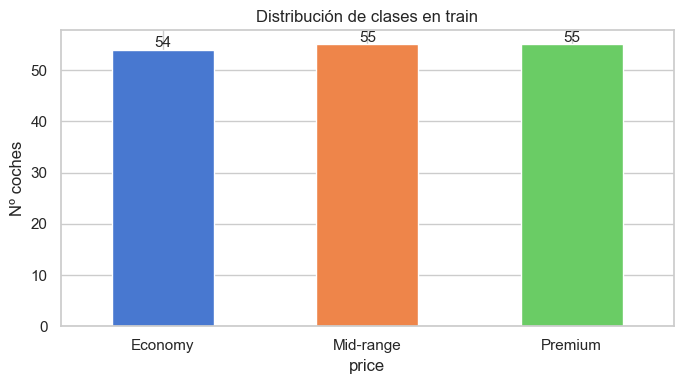

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['Economy', 'Mid-range', 'Premium']
colors = ['#4878D0', '#EE854A', '#6ACC65']

y_train.value_counts()[order].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Distribución de clases en train')
ax.set_ylabel('Nº coches')
ax.set_xticklabels(order, rotation=0)

for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 5.2 Separación de clases: features numéricas

El gráfico más útil para clasificación con features numéricas es el **boxplot por clase**. Nos muestra si los valores de una feature son distintos según la clase.

Una feature ideal para el modelo es aquella donde los tres boxplots NO se solapan.

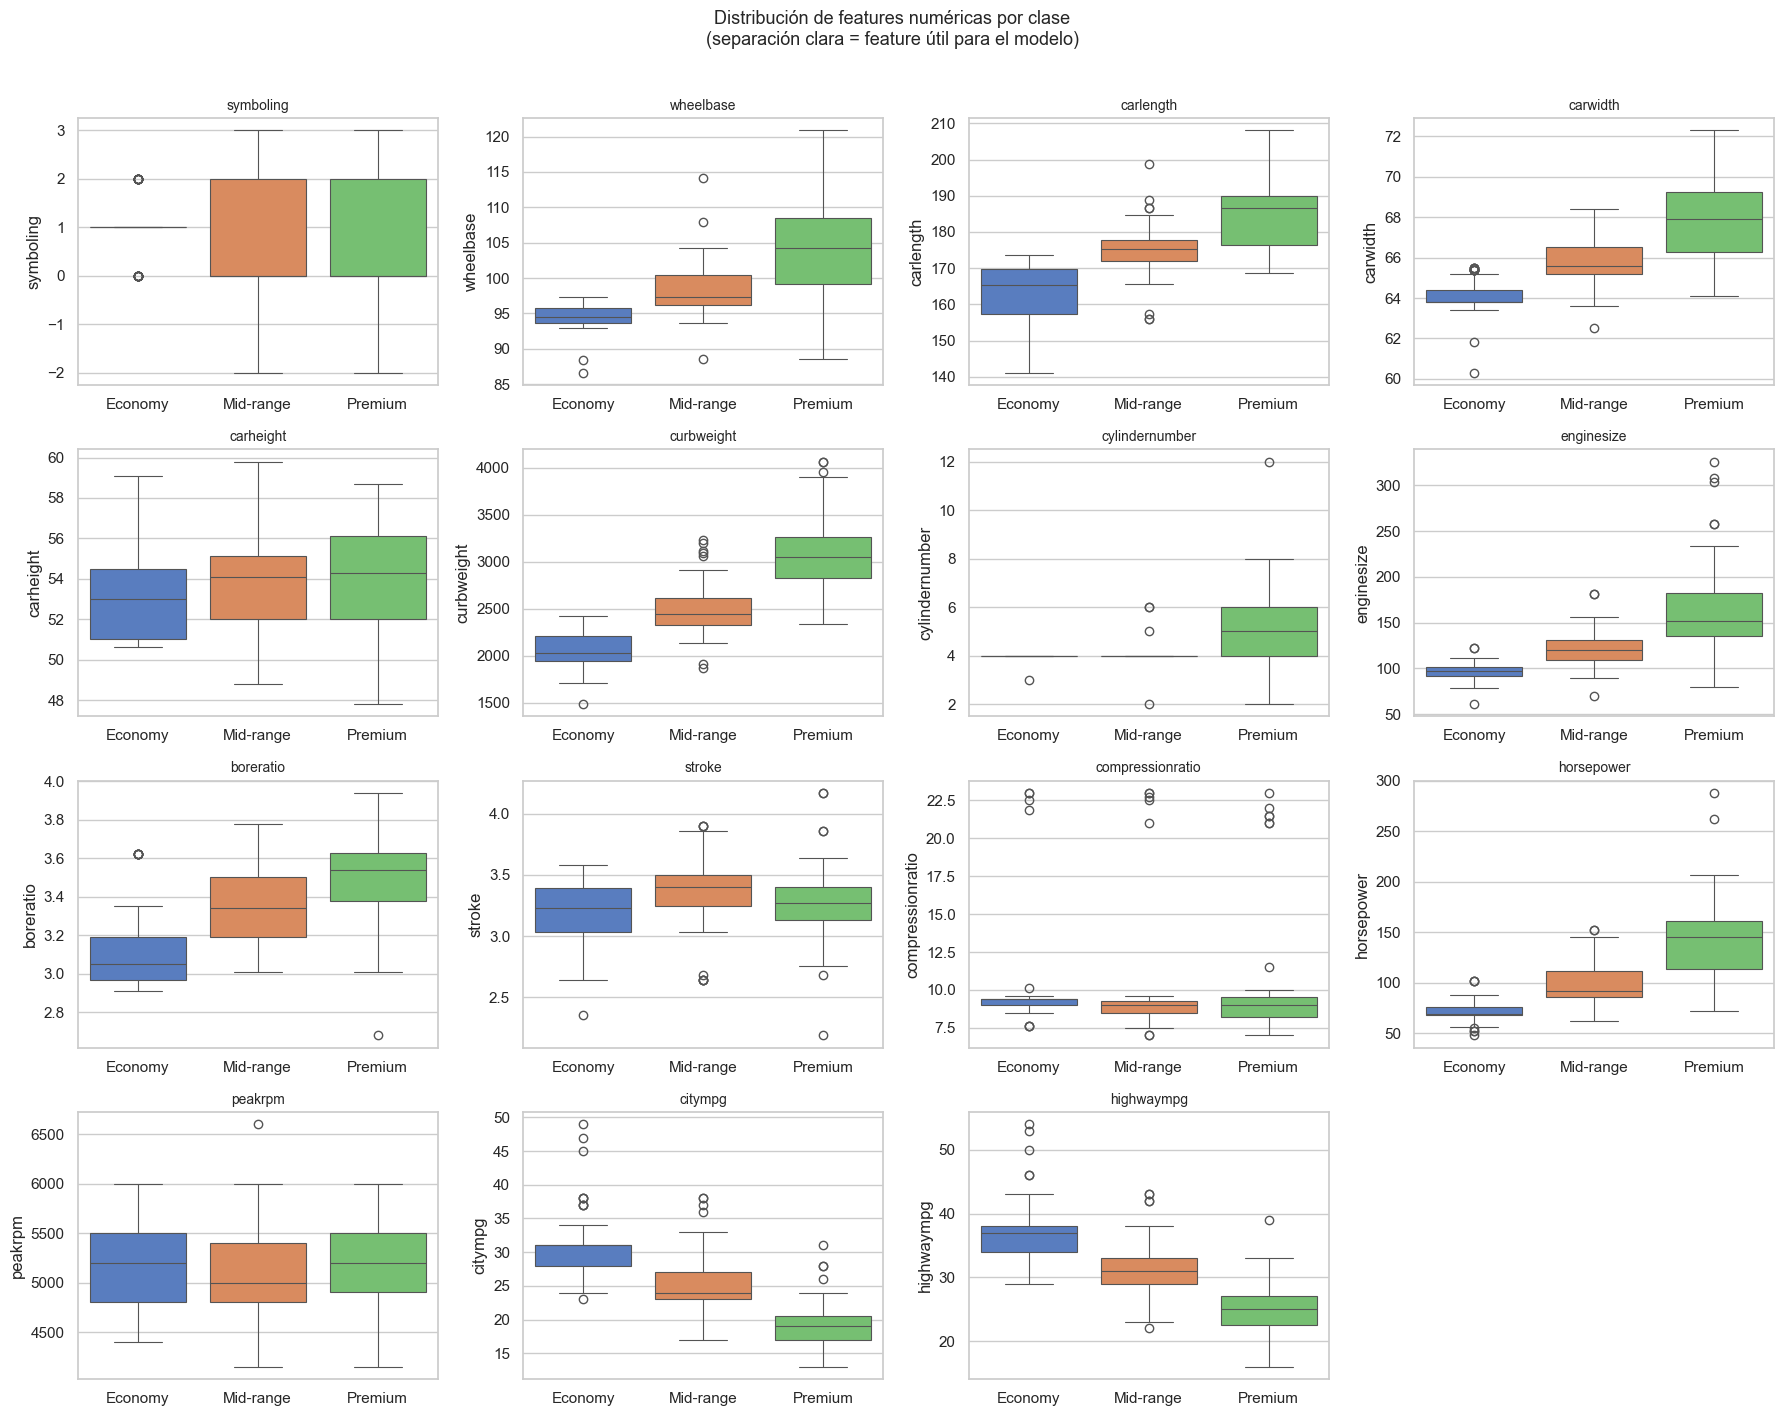

In [8]:
df_eda = X_train.select_dtypes('number').copy()
df_eda['clase'] = y_train.values

num_features = [c for c in df_eda.columns if c != 'clase']
n = len(num_features)
cols_grid = 4
rows_grid = (n + cols_grid - 1) // cols_grid

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(18, rows_grid * 3.5))
axes = axes.flatten()

order = ['Economy', 'Mid-range', 'Premium']
palette = {'Economy': '#4878D0', 'Mid-range': '#EE854A', 'Premium': '#6ACC65'}

for ax, feat in zip(axes, num_features):
    sns.boxplot(data=df_eda, x='clase', y=feat, order=order,
                palette=palette, ax=ax, linewidth=0.8)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')

# Ocultar ejes vacíos
for ax in axes[len(num_features):]:
    ax.set_visible(False)

plt.suptitle('Distribución de features numéricas por clase\n'
             '(separación clara = feature útil para el modelo)',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

> **Qué buscar:** Features como `enginesize`, `horsepower` y `curbweight` deberían mostrar boxplots bien separados (Premium claramente por encima de Economy). Si los boxplots se solapan mucho, la feature tiene poca capacidad discriminativa.
>
> **El reto de este dataset:** Economy y Mid-range son clases adyacentes con mucho solapamiento. El modelo cometerá más errores entre estas dos clases que entre Economy y Premium. Lo veremos claramente en la matriz de confusión.

### 5.3 Features categóricas por clase

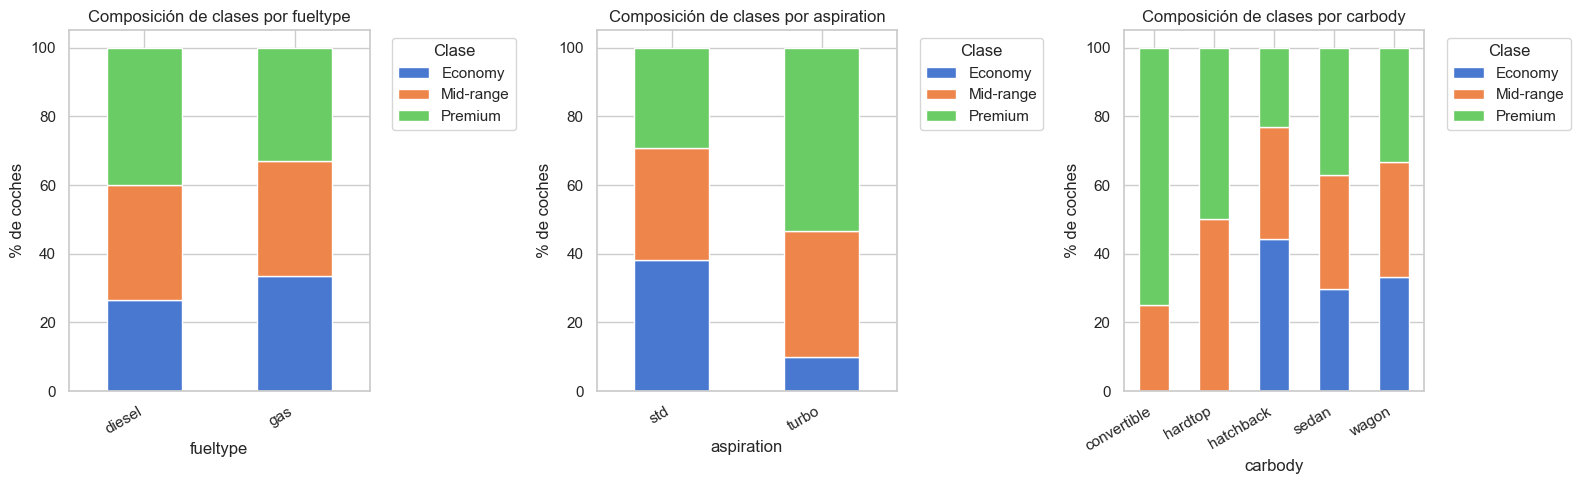

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_cat = X_train[['fueltype', 'aspiration', 'carbody']].copy()
df_cat['clase'] = y_train.values

for ax, feat in zip(axes, ['fueltype', 'aspiration', 'carbody']):
    ct = df_cat.groupby([feat, 'clase']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct[order].plot(kind='bar', ax=ax, color=list(palette.values()),
                       edgecolor='white', stacked=True)
    ax.set_title(f'Composición de clases por {feat}')
    ax.set_ylabel('% de coches')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Clase', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### 5.4 Precio mediano por marca y clase

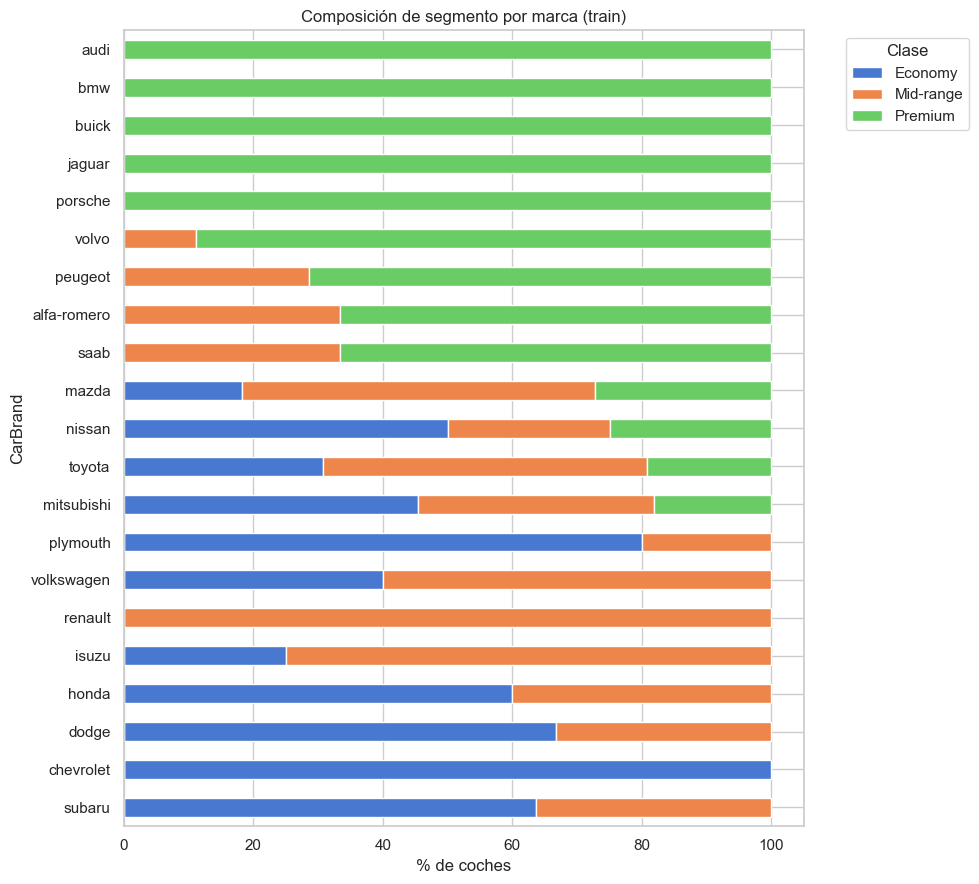

In [10]:
df_brand = X_train[['CarBrand']].copy()
df_brand['clase'] = y_train.values

brand_class = df_brand.groupby(['CarBrand', 'clase']).size().unstack(fill_value=0)
brand_class_pct = brand_class.div(brand_class.sum(axis=1), axis=0) * 100

# Ordenar por proporción de Premium
brand_class_pct = brand_class_pct.sort_values('Premium', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
brand_class_pct[order].plot(kind='barh', stacked=True, ax=ax,
                             color=list(palette.values()), edgecolor='white')
ax.set_title('Composición de segmento por marca (train)', fontsize=12)
ax.set_xlabel('% de coches')
ax.legend(title='Clase', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Paso 6: Tratamiento de variables

El tratamiento es casi idéntico al de regresión, con **una diferencia importante**:

| | Regresión | Clasificación |
|---|---|---|
| **Target** | log1p(price) continuo | Categoría ordinal (no se transforma) |
| **Features** | Igual | Igual |
| **Escalado** | Igual | Igual |
| **Encoding** | Igual | Igual |

Ya no necesitamos transformar la target — es una etiqueta de clase.

### 6.7 Transformación de features numéricas sesgadas

In [11]:
num_cols = X_train.select_dtypes('number').columns.tolist()

# Features con skew > 1 y sin negativos
cols_log = [c for c in num_cols if abs(X_train[c].skew()) > 1 and X_train[c].min() >= 0]
print(f"Features con skew > 1 → log1p: {cols_log}")

for col in cols_log:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

Features con skew > 1 → log1p: ['wheelbase', 'cylindernumber', 'enginesize', 'compressionratio', 'horsepower']


### 6.8 Encodings

In [12]:
# Encoding binario
binary_maps = {
    'fueltype':       {'gas': 1, 'diesel': 0},
    'aspiration':     {'std': 0, 'turbo': 1},
    'doornumber':     {'two': 0, 'four': 1},
    'enginelocation': {'front': 1, 'rear': 0},
}
for col, mapping in binary_maps.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping)

# OneHot encoding
cat_cols_ohe = ['carbody', 'drivewheel', 'enginetype', 'fuelsystem', 'CarBrand']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

ohe_train = encoder.fit_transform(X_train[cat_cols_ohe])
ohe_test  = encoder.transform(X_test[cat_cols_ohe])
ohe_names = encoder.get_feature_names_out(cat_cols_ohe)

X_train = pd.concat([
    X_train.drop(columns=cat_cols_ohe),
    pd.DataFrame(ohe_train, columns=ohe_names, index=X_train.index)
], axis=1)
X_test = pd.concat([
    X_test.drop(columns=cat_cols_ohe),
    pd.DataFrame(ohe_test, columns=ohe_names, index=X_test.index)
], axis=1)

print(f"Shape tras encoding: X_train {X_train.shape}  |  X_test {X_test.shape}")

Shape tras encoding: X_train (164, 58)  |  X_test (41, 58)


### 6.9 Escalado

In [13]:
num_cols_final = X_train.select_dtypes('number').columns.tolist()
num_cols_to_scale = [c for c in num_cols_final if c not in list(ohe_names)]

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print(f"Columnas escaladas: {len(num_cols_to_scale)}")
print(f"Total features listas para el modelo: {X_train.shape[1]}")

Columnas escaladas: 19
Total features listas para el modelo: 58


## Paso 7: Elección de métricas

### ¿Cuál es la métrica principal para este problema?

**Respuesta: F1-score macro**

Razonamos paso a paso:

---

#### ¿Por qué no accuracy?

Con clases balanceadas (≈33 % cada una) accuracy podría parecer razonable. Pero si el modelo aprendiese a predecir siempre "Mid-range" (la clase más fácil), tendría ~33 % de accuracy y **no detectaría ningún Economy ni Premium**. Accuracy no nos dice cuántos errores hay por clase.

#### ¿Por qué F1 y no Precision o Recall por separado?

En este problema **no hay un tipo de error que sea claramente más grave que otro**. No estamos detectando fraude (donde el FN es catastrófico) ni filtrando spam (donde el FP es más costoso). Errar entre Economy y Mid-range es parecido a errar entre Mid-range y Premium: el coste es similar. F1 equilibra Precision y Recall.

#### ¿Por qué F1 macro y no weighted?

- **F1 macro**: calcula F1 por clase y hace la media aritmética. Trata todos los segmentos por igual.
- **F1 weighted**: hace la media ponderada por frecuencia. Como nuestras clases están balanceadas (≈33 % cada una), el resultado es casi idéntico. Si las clases fueran desbalanceadas, la elección importaría más.

Con qcut las clases son balanceadas → macro y weighted convergen. Usamos **macro** porque expresa explícitamente que no queremos favorecer ningún segmento.

---

#### La matriz de confusión como herramienta principal de diagnóstico

La métrica única (F1 = 0.78) no te dice si el modelo falla entre clases adyacentes (Economy ↔ Mid-range, errores "perdoneables") o entre clases extremas (Economy ↔ Premium, errores más graves). La matriz de confusión sí te lo dice.

In [14]:
# Función de evaluación reutilizable
def evaluar_clasificador(nombre, modelo, X_tr, y_tr, X_te, y_te):
    y_tr_pred = modelo.predict(X_tr)
    y_te_pred = modelo.predict(X_te)

    order = ['Economy', 'Mid-range', 'Premium']

    print(f"{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"  Train Accuracy: {accuracy_score(y_tr, y_tr_pred):.3f}")
    print(f"  Test  Accuracy: {accuracy_score(y_te, y_te_pred):.3f}")
    print(f"  Train F1 macro: {f1_score(y_tr, y_tr_pred, average='macro'):.3f}")
    print(f"  Test  F1 macro: {f1_score(y_te, y_te_pred, average='macro'):.3f}")
    print()
    print("  Classification report (test):")
    print(classification_report(y_te, y_te_pred, target_names=order))

    # Matriz de confusión
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_te_pred,
        display_labels=order,
        cmap='Blues',
        ax=ax,
        colorbar=False
    )
    ax.set_title(f'Matriz de confusión — {nombre}\n'
                 f'(fila = real, columna = predicho)')
    plt.tight_layout()
    plt.show()

    return f1_score(y_te, y_te_pred, average='macro')

## Paso 8: Selección del modelo

Del EDA sabemos que las features separan bien las clases extremas (Economy vs Premium), pero hay solapamiento entre las adyacentes. Las relaciones parecen razonablemente lineales en el espacio log-transformado.

**Usamos `LogisticRegression`** con regularización:
- Adecuada para clasificación multiclase con features linealmente separables.
- Con >40 features y <170 observaciones de train, la regularización es necesaria.
- `multi_class='multinomial'` (softmax): entrena un único clasificador para las 3 clases simultáneamente.
- `solver='saga'`: soporta tanto L1 como L2 en multiclase → ideal para comparar ambas.

> 💡 Recuerda: en `LogisticRegression`, el parámetro de regularización es `C`, **no `alpha`**. Y funciona al revés: **`C` alto = menos regularización** (C = 1/alpha).

## Paso 9: Entrenamiento — Baseline

  LogisticRegression Baseline
  Train Accuracy: 0.915
  Test  Accuracy: 0.805
  Train F1 macro: 0.914
  Test  F1 macro: 0.795

  Classification report (test):
              precision    recall  f1-score   support

     Economy       0.88      1.00      0.93        14
   Mid-range       0.80      0.57      0.67        14
     Premium       0.73      0.85      0.79        13

    accuracy                           0.80        41
   macro avg       0.80      0.81      0.80        41
weighted avg       0.80      0.80      0.80        41



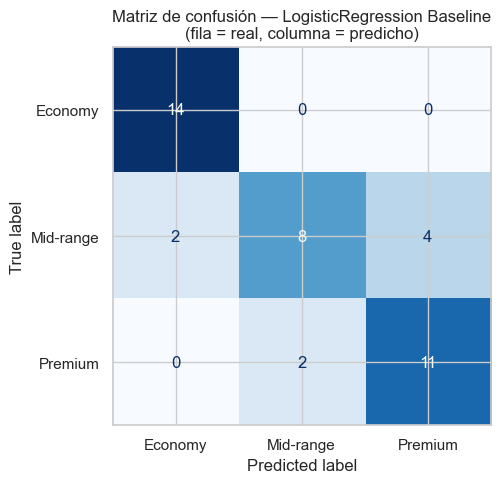

In [15]:
# Baseline: LogisticRegression sin ajustar hiperparámetros
lr_base = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='saga',
    max_iter=2000,
    random_state=42
)
lr_base.fit(X_train, y_train)

f1_base = evaluar_clasificador('LogisticRegression Baseline', lr_base, X_train, y_train, X_test, y_test)

> **Cómo leer la matriz de confusión:**
> - Las filas son la clase **real**, las columnas la clase **predicha**.
> - La diagonal principal son los aciertos.
> - Los errores más "graves" son los que están lejos de la diagonal (esquinas: Economy predicho como Premium o viceversa).
> - Los errores más "perdonables" son los adyacentes a la diagonal (Economy ↔ Mid-range, Mid-range ↔ Premium).
>
> Para este dataset, esperamos ver más errores en la frontera Economy/Mid-range que en Economy/Premium.

## Paso 10: Regularización — búsqueda del C óptimo

Comparamos L1 y L2 con validación cruzada para encontrar el mejor nivel de regularización.

Con L1 esperamos que algunos coeficientes queden a cero (selección implícita de features). Con L2, todos se reducen proporcionalmente pero ninguno se anula.

In [16]:
# ── GridSearch para L2 (Ridge-like)
grid_l2 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='saga',
                       max_iter=2000, random_state=42),
    param_grid={'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_l2.fit(X_train, y_train)

print(f"L2 — Mejor C: {grid_l2.best_params_['C']}")
print(f"L2 — Mejor F1 macro en CV: {grid_l2.best_score_:.3f}")

L2 — Mejor C: 0.05
L2 — Mejor F1 macro en CV: 0.780


In [17]:
# ── GridSearch para L1 (Lasso-like)
grid_l1 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga',
                       max_iter=2000, random_state=42),
    param_grid={'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_l1.fit(X_train, y_train)

print(f"L1 — Mejor C: {grid_l1.best_params_['C']}")
print(f"L1 — Mejor F1 macro en CV: {grid_l1.best_score_:.3f}")

L1 — Mejor C: 0.1
L1 — Mejor F1 macro en CV: 0.815


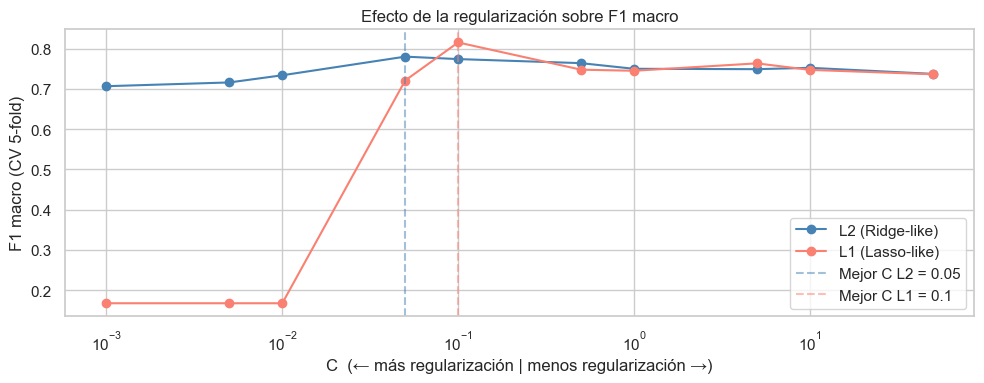

In [ ]:
# ── Ruta de regularización: cómo cambia F1 con distintos valores de C
fig, ax = plt.subplots(figsize=(10, 4))

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

for penalty, color, label in [('l2', 'steelblue', 'L2 (Ridge-like)'),
                                ('l1', 'salmon',    'L1 (Lasso-like)')]:
    cv_scores = []
    for c in C_values:
        modelo = LogisticRegression(
            penalty=penalty, C=c, solver='saga', max_iter=2000, random_state=42
        )
        scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1_macro')
        cv_scores.append(scores.mean())
    ax.plot(C_values, cv_scores, marker='o', color=color, label=label)

ax.set_xscale('log')
ax.axvline(grid_l2.best_params_['C'], color='steelblue', linestyle='--', alpha=0.5, label=f"Mejor C L2 = {grid_l2.best_params_['C']}")
ax.axvline(grid_l1.best_params_['C'], color='salmon',    linestyle='--', alpha=0.5, label=f"Mejor C L1 = {grid_l1.best_params_['C']}")
ax.set_xlabel('C  (← más regularización | menos regularización →)')
ax.set_ylabel('F1 macro (CV 5-fold)')
ax.set_title('Efecto de la regularización sobre F1 macro')
ax.legend()
plt.tight_layout()
plt.show()

L1: 53/58 features eliminadas (91 %)



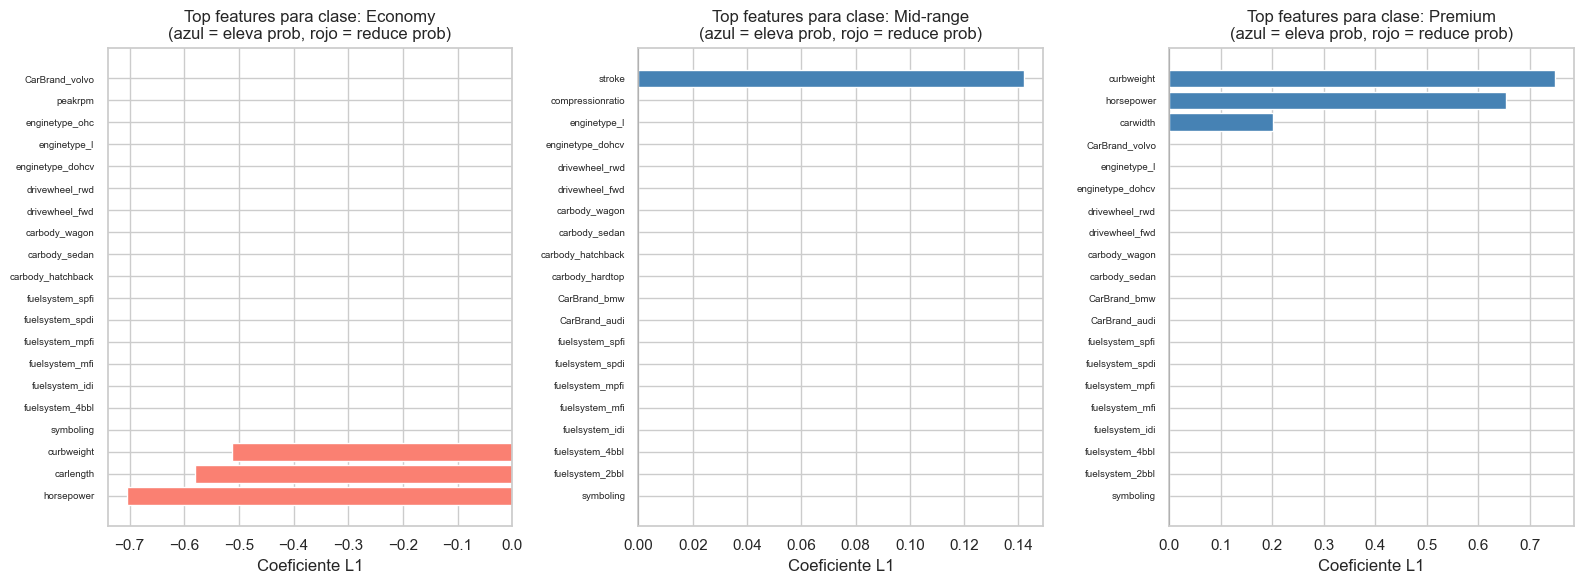

In [19]:
# ── Coeficientes del mejor modelo L1: ¿qué features anuló?
best_l1 = grid_l1.best_estimator_
best_l2 = grid_l2.best_estimator_

# Contamos features con todos los coeficientes ≈ 0 en L1 (eliminadas para todas las clases)
coef_l1 = best_l1.coef_  # shape: (n_clases, n_features)
n_eliminadas = (np.abs(coef_l1).max(axis=0) < 1e-4).sum()
print(f"L1: {n_eliminadas}/{X_train.shape[1]} features eliminadas ({n_eliminadas/X_train.shape[1]*100:.0f} %)")
print()

# Top features por peso promedio en valor absoluto (L1)
avg_coef = np.abs(coef_l1).mean(axis=0)
top_idx  = np.argsort(avg_coef)[-15:]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
order_clases = ['Economy', 'Mid-range', 'Premium']

for ax, i_clase, nombre_clase in zip(axes, [0, 1, 2], order_clases):
    coefs = best_l1.coef_[i_clase]
    sorted_idx = np.argsort(coefs)
    top20 = list(sorted_idx[:10]) + list(sorted_idx[-10:])
    colors = ['salmon' if c < 0 else 'steelblue' for c in coefs[top20]]
    ax.barh(range(len(top20)), coefs[top20], color=colors)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels([X_train.columns[j] for j in top20], fontsize=7)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_title(f'Top features para clase: {nombre_clase}\n(azul = eleva prob, rojo = reduce prob)')
    ax.set_xlabel('Coeficiente L1')

plt.tight_layout()
plt.show()

## Paso 11: Evaluación comparativa



  LogisticRegression L2
  Train Accuracy: 0.854
  Test  Accuracy: 0.829
  Train F1 macro: 0.853
  Test  F1 macro: 0.819

  Classification report (test):
              precision    recall  f1-score   support

     Economy       0.88      1.00      0.93        14
   Mid-range       0.89      0.57      0.70        14
     Premium       0.75      0.92      0.83        13

    accuracy                           0.83        41
   macro avg       0.84      0.83      0.82        41
weighted avg       0.84      0.83      0.82        41



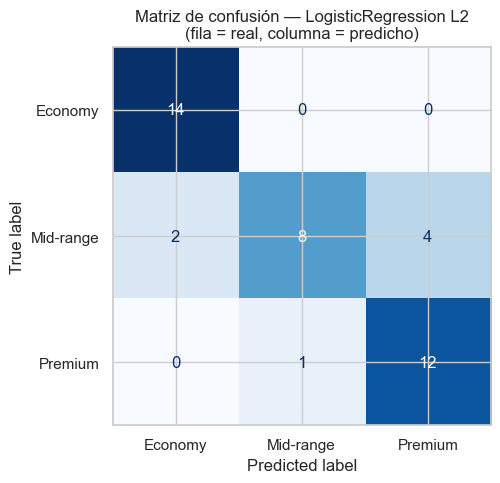



  LogisticRegression L1
  Train Accuracy: 0.829
  Test  Accuracy: 0.854
  Train F1 macro: 0.829
  Test  F1 macro: 0.844

  Classification report (test):
              precision    recall  f1-score   support

     Economy       0.93      1.00      0.97        14
   Mid-range       1.00      0.57      0.73        14
     Premium       0.72      1.00      0.84        13

    accuracy                           0.85        41
   macro avg       0.89      0.86      0.84        41
weighted avg       0.89      0.85      0.84        41



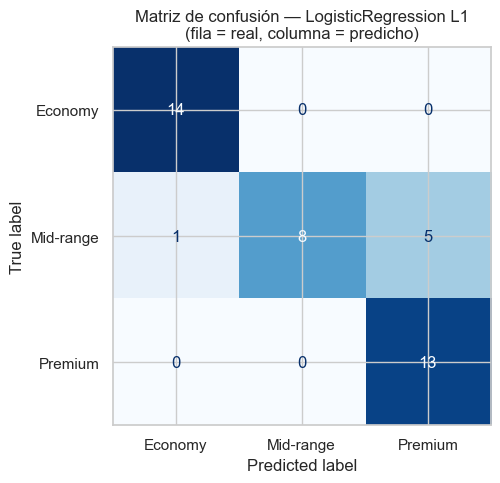

In [20]:
print("\n")
f1_l2 = evaluar_clasificador('LogisticRegression L2', best_l2, X_train, y_train, X_test, y_test)
print("\n")
f1_l1 = evaluar_clasificador('LogisticRegression L1', best_l1, X_train, y_train, X_test, y_test)

In [21]:
# ── Tabla resumen de los tres modelos
resultados = []

for nombre, modelo in [
    ('LR Baseline (L2, C=1)', lr_base),
    (f'LR L2 (C={grid_l2.best_params_["C"]})', best_l2),
    (f'LR L1 (C={grid_l1.best_params_["C"]})', best_l1),
]:
    ytr = modelo.predict(X_train)
    yte = modelo.predict(X_test)
    resultados.append({
        'Modelo':           nombre,
        'Train F1 macro':   round(f1_score(y_train, ytr, average='macro'), 3),
        'Test  F1 macro':   round(f1_score(y_test,  yte, average='macro'), 3),
        'Gap':              round(f1_score(y_train, ytr, average='macro') - f1_score(y_test, yte, average='macro'), 3),
        'Test Accuracy':    round(accuracy_score(y_test, yte), 3),
    })

print(pd.DataFrame(resultados).to_string(index=False))
print()
print("Gap pequeño (< 0.05) = modelo que generaliza bien. Gap grande = overfitting.")

               Modelo  Train F1 macro  Test  F1 macro    Gap  Test Accuracy
LR Baseline (L2, C=1)           0.914           0.795  0.119          0.805
       LR L2 (C=0.05)           0.853           0.819  0.034          0.829
        LR L1 (C=0.1)           0.829           0.844 -0.015          0.854

Gap pequeño (< 0.05) = modelo que generaliza bien. Gap grande = overfitting.


In [22]:
# ── Cross-validation del mejor modelo sobre train
best_model = best_l2 if f1_l2 >= f1_l1 else best_l1
mejor_nombre = 'L2' if f1_l2 >= f1_l1 else 'L1'

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_macro')
print(f"Mejor modelo: {mejor_nombre}")
print(f"CV F1 macro (5-fold sobre train): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test F1 macro: {max(f1_l1, f1_l2):.3f}")
print()
print("Si CV F1 ≈ Test F1, el modelo generaliza correctamente.")

Mejor modelo: L1
CV F1 macro (5-fold sobre train): 0.815 ± 0.055
Test F1 macro: 0.844

Si CV F1 ≈ Test F1, el modelo generaliza correctamente.


### Interpretación de la matriz de confusión

La matriz de confusión es el análisis final más importante. Busca estas tres cosas:

**1. Diagonal alta** — los tres valores en la diagonal deben ser los más altos de su fila. Cada clase se predice correctamente en la mayoría de los casos.

**2. Errores adyacentes > errores lejanos** — los errores en las casillas (Economy→Mid-range) y (Mid-range→Premium) deben ser mayores que los errores en las esquinas (Economy→Premium). Si esto se cumple, el modelo al menos "sabe" que un coche está cerca del límite de dos segmentos; no confunde extremos.

**3. Asimetría de errores** — ¿se equivoca más prediciendo "hacia arriba" o "hacia abajo"? Si predice más Premium cuando es Mid-range que al revés, el modelo tiene un sesgo positivo.

## Paso 12: Conclusión

### Resumen del problema de clasificación

| Decisión | Elección | Justificación |
|---|---|---|
| **Target** | 3 clases por terciles (qcut) | Clases balanceadas, separación natural por segmento de mercado |
| **Métrica principal** | F1 macro | Clases balanceadas + coste simétrico entre errores |
| **Target leakage** | Price eliminado obligatoriamente | Es la columna de la que deriva la target |
| **Split** | stratify=y | Con solo 41 muestras en test, garantiza representación de las 3 clases |
| **Modelo** | LogisticRegression multinomial | Relaciones mayormente lineales, pocos datos, muchas features |
| **Regularización** | L2 o L1 según GridSearch | Necesaria con >40 features y <170 muestras de train |

### Diferencias clave respecto al problema de regresión

| | Regresión | Clasificación |
|---|---|---|
| **Target** | log1p(price) continuo | 3 clases (Economy / Mid-range / Premium) |
| **Métrica** | RMSE, R² | F1 macro |
| **Modelo** | Ridge, Lasso | LogisticRegression (L1/L2) |
| **EDA target** | Histograma + boxplot del precio | Countplot de distribución de clases |
| **EDA features** | Scatterplot vs price | Boxplot por clase |
| **Interpretación errores** | RMSE en USD | Matriz de confusión |
| **Errores "más graves"** | Todos los $ igual | Economy ↔ Premium (clases extremas) |

### Redacción de resultados para un stakeholder

> *El modelo clasifica coches en tres segmentos de mercado (Economy, Mid-range, Premium) con un F1-score macro de X sobre datos no vistos, equivalente a Y % de aciertos. Los principales determinantes del segmento son el tamaño del motor, la potencia y la marca. El modelo comete más errores en la frontera Economy/Mid-range que entre los segmentos extremos, lo cual es esperable dado el solapamiento de características entre coches de gama media-baja. Recomendamos usar el modelo como herramienta de apoyo para clasificación inicial de inventario, revisando manualmente los casos donde la probabilidad de la clase predicha sea inferior al 70 %.*

### Limitaciones
- 205 coches en total: el modelo es sensible al split aleatorio; los resultados pueden variar ±3–5 puntos de F1.
- Los umbrales de precio vienen del dataset histórico y pueden no reflejar el mercado actual.
- Clases adyacentes (Economy/Mid-range) tienen solapamiento intrínseco — un modelo más complejo (Random Forest, Gradient Boosting) podría capturar mejores fronteras no lineales.